In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
df = pd.read_csv("../data/base3_phishing_websites/base_phishing_sites.csv")

linhas_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Linhas removidas por duplicidade: {linhas_antes - len(df)} (restam {len(df)})")

df["target"] = (df["Result"] == -1).astype(int)
df = df.drop(columns="Result")

Linhas removidas por duplicidade: 5206 (restam 5849)


In [2]:
contagem_classes = df.groupby("target")["target"].count()
total = contagem_classes.sum()
porcentagem_classes = contagem_classes / total * 100
print(porcentagem_classes)

target
0    48.384339
1    51.615661
Name: target, dtype: float64


In [3]:
X = df.drop(columns="target")
y = df["target"]

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("Desenvolvimento:", X_dev.shape, " Teste:", X_test.shape)

Desenvolvimento: (4386, 30)  Teste: (1463, 30)


In [4]:
validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

colunas_categoricas = X.columns.tolist()
pre_processamento = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas)
])

In [6]:
from sklearn.linear_model import LogisticRegression

pipe_logreg = Pipeline([
    ("pre", pre_processamento),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])

parametros_logreg = {
    "clf__C": [0.01, 0.1, 0.3, 1, 3, 10, 30],
    "clf__class_weight": [None, "balanced"],
}

busca_logreg = RandomizedSearchCV(
    pipe_logreg, parametros_logreg, n_iter=10,
    scoring="f1",
    cv=validacao, random_state=42, n_jobs=-1,
)
busca_logreg.fit(X_dev, y_dev)

print("Regressão Logística — melhores hiperparâmetros:", busca_logreg.best_params_)
print("Regressão Logística — F1 médio na validação:", round(busca_logreg.best_score_, 4))

Regressão Logística — melhores hiperparâmetros: {'clf__class_weight': 'balanced', 'clf__C': 0.3}
Regressão Logística — F1 médio na validação: 0.9408


In [7]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("pre", pre_processamento),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

parametros_rf = {
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [None, 10, 20, 30],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"],
    "clf__class_weight": [None, "balanced"],
}

busca_rf = RandomizedSearchCV(
    pipe_rf, parametros_rf, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_rf.fit(X_dev, y_dev)

print("Random Forest — melhores hiperparâmetros:", busca_rf.best_params_)
print("Random Forest — F1 médio na validação:", round(busca_rf.best_score_, 4))

Random Forest — melhores hiperparâmetros: {'clf__n_estimators': 300, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': None, 'clf__class_weight': 'balanced'}
Random Forest — F1 médio na validação: 0.9496


In [8]:
from sklearn.ensemble import GradientBoostingClassifier

pipe_gb = Pipeline([
    ("pre", pre_processamento),
    ("clf", GradientBoostingClassifier(random_state=42)),
])

parametros_gb = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__max_depth": [2, 3, 4],
    "clf__subsample": [0.7, 0.85, 1.0],
}

busca_gb = RandomizedSearchCV(
    pipe_gb, parametros_gb, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_gb.fit(X_dev, y_dev)

print("Gradient Boosting — melhores hiperparâmetros:", busca_gb.best_params_)
print("Gradient Boosting — F1 médio na validação:", round(busca_gb.best_score_, 4))

Gradient Boosting — melhores hiperparâmetros: {'clf__subsample': 0.85, 'clf__n_estimators': 300, 'clf__max_depth': 4, 'clf__learning_rate': 0.1}
Gradient Boosting — F1 médio na validação: 0.9527


In [9]:
resultados = {
    "Regressão Logística": busca_logreg,
    "Random Forest": busca_rf,
    "Gradient Boosting": busca_gb,
}

for nome, busca in resultados.items():
    print(f"{nome:22s} F1 médio (validação) = {busca.best_score_:.4f}")

melhor_nome = max(resultados, key=lambda k: resultados[k].best_score_)
melhor_modelo = resultados[melhor_nome].best_estimator_
print(f"\nModelo selecionado: {melhor_nome}")

Regressão Logística    F1 médio (validação) = 0.9408
Random Forest          F1 médio (validação) = 0.9496
Gradient Boosting      F1 médio (validação) = 0.9527

Modelo selecionado: Gradient Boosting


Acurácia:  0.9556
Precisão:  0.9662
Recall:    0.9470
F1-score:  0.9565
AUC-ROC:            0.9924
AUC-PR (trapézio):   0.9935
Average Precision:   0.9935


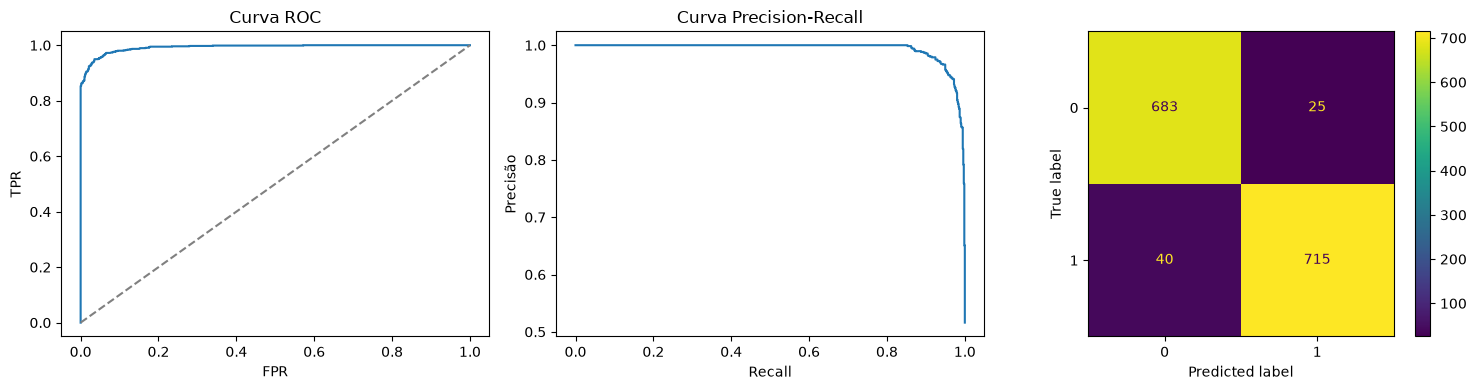

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    average_precision_score, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

y_pred = melhor_modelo.predict(X_test)
y_prob = melhor_modelo.predict_proba(X_test)[:, 1]

print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
precisao_c, recall_c, _ = precision_recall_curve(y_test, y_prob)
auc_roc = roc_auc_score(y_test, y_prob)
auc_pr_trapezio = auc(recall_c, precisao_c)
average_precision = average_precision_score(y_test, y_prob)

print(f"AUC-ROC:            {auc_roc:.4f}")
print(f"AUC-PR (trapézio):   {auc_pr_trapezio:.4f}")
print(f"Average Precision:   {average_precision:.4f}")

fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
eixos[0].plot(fpr, tpr); eixos[0].plot([0, 1], [0, 1], "--", color="gray")
eixos[0].set_title("Curva ROC"); eixos[0].set_xlabel("FPR"); eixos[0].set_ylabel("TPR")
eixos[1].plot(recall_c, precisao_c)
eixos[1].set_title("Curva Precision-Recall"); eixos[1].set_xlabel("Recall"); eixos[1].set_ylabel("Precisão")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=eixos[2])
plt.tight_layout(); plt.show()

c:\Users\guilh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


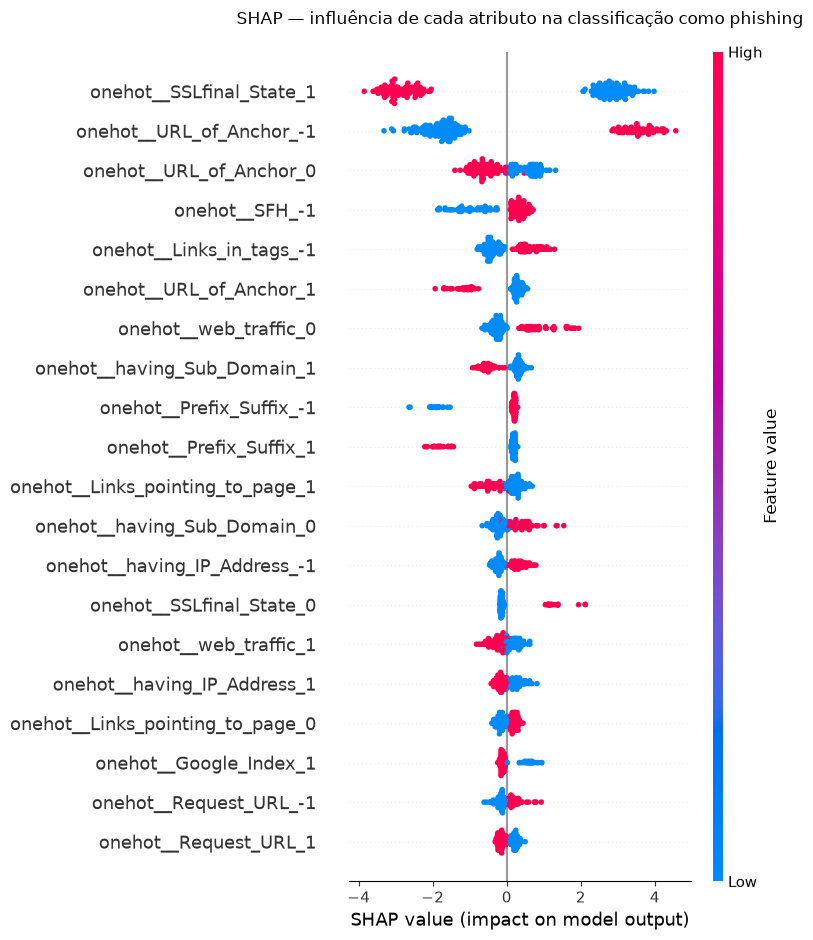

In [11]:
import shap

pre_ajustado = melhor_modelo.named_steps["pre"]
clf_ajustado = melhor_modelo.named_steps["clf"]
nomes_atributos = pre_ajustado.get_feature_names_out()

X_test_codificado = pre_ajustado.transform(X_test)
if hasattr(X_test_codificado, "toarray"):
    X_test_codificado = X_test_codificado.toarray()

rng = np.random.default_rng(42)
quantidade_amostras = min(200, X_test_codificado.shape[0])
indices_shap = rng.choice(X_test_codificado.shape[0], size=quantidade_amostras, replace=False)

X_shap = pd.DataFrame(X_test_codificado[indices_shap], columns=nomes_atributos)

explainer = shap.TreeExplainer(clf_ajustado)
valores_shap = explainer(X_shap)

shap.summary_plot(
    valores_shap.values, X_shap, feature_names=nomes_atributos,
    plot_type="dot", max_display=20, show=False,
)
plt.title("SHAP — influência de cada atributo na classificação como phishing", pad=20)
plt.tight_layout(); plt.show()

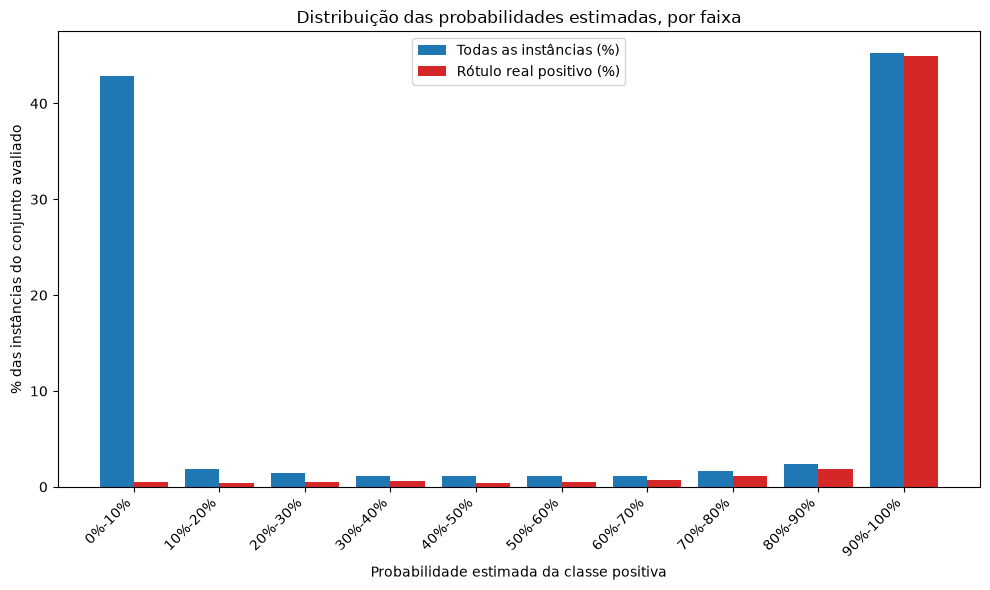

      faixa  contagem_total  pct_total  contagem_positivos  \
0    0%-10%            1880  42.863657                  20   
1   10%-20%              80   1.823985                  19   
2   20%-30%              63   1.436389                  23   
3   30%-40%              50   1.139991                  27   
4   40%-50%              51   1.162791                  19   
5   50%-60%              49   1.117191                  23   
6   60%-70%              51   1.162791                  30   
7   70%-80%              73   1.664387                  50   
8   80%-90%             104   2.371181                  80   
9  90%-100%            1985  45.257638                1973   

   pct_positivos_na_faixa  
0                1.063830  
1               23.750000  
2               36.507937  
3               54.000000  
4               37.254902  
5               46.938776  
6               58.823529  
7               68.493151  
8               76.923077  
9               99.395466  


In [12]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

from parte1_grafico_pontos_corte.histograma_grafico_e_faixas import plot_corte

proba_oof = cross_val_predict(melhor_modelo, X_dev, y_dev, cv=validacao, method="predict_proba")[:, 1]

fig, ax, tabela_validacao, _ = plot_corte(y_dev.values, proba_oof, bin_width=10)
plt.show()
print(tabela_validacao)

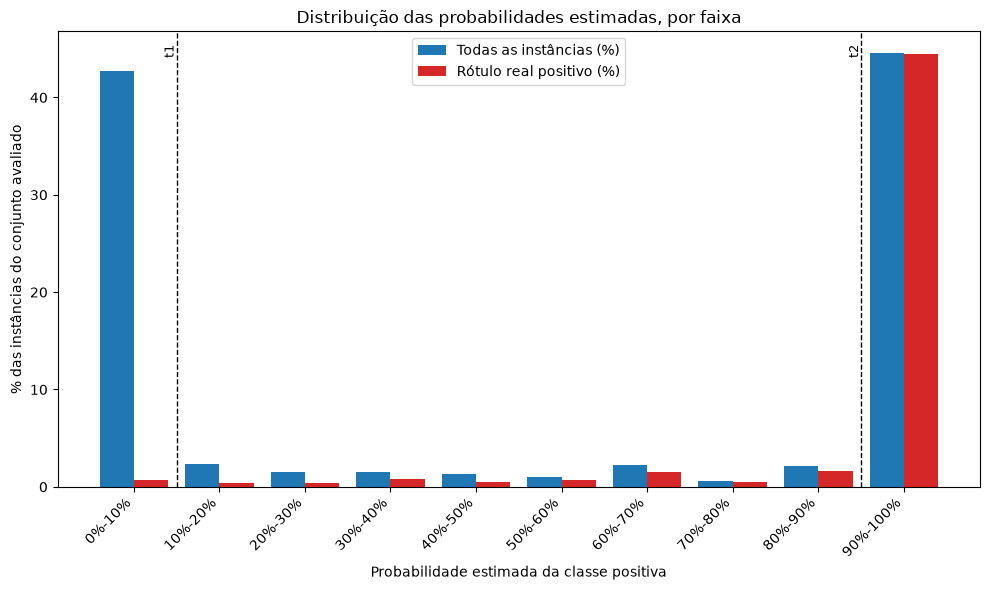

      faixa  contagem_total  pct_total  contagem_positivos  \
0    0%-10%             625  42.720437                  10   
1   10%-20%              34   2.323992                   6   
2   20%-30%              23   1.572112                   5   
3   30%-40%              22   1.503759                  12   
4   40%-50%              19   1.298701                   7   
5   50%-60%              15   1.025290                  10   
6   60%-70%              33   2.255639                  23   
7   70%-80%               9   0.615174                   7   
8   80%-90%              31   2.118934                  24   
9  90%-100%             652  44.565960                 651   

   pct_positivos_na_faixa  
0                1.600000  
1               17.647059  
2               21.739130  
3               54.545455  
4               36.842105  
5               66.666667  
6               69.696970  
7               77.777778  
8               77.419355  
9               99.846626  
{'t1': 10

In [13]:
melhor_modelo.fit(X_dev, y_dev)
proba_teste = melhor_modelo.predict_proba(X_test)[:, 1]

fig, ax, tabela_teste, metricas = plot_corte(
    y_test.values, proba_teste, bin_width=10, t1=10, t2=90
)
plt.show()
print(tabela_teste)
print(metricas)